# CURRENT TO\-DOS :

- [ ] Organized, clear notebook \-\-\- review \+ revise

- [ ] Figures for blog \(prioritize Pringsheim stuff\)

- [ ] need to edit plotting at end so that it works with test customization

# Other things to try:

- [ ] method to shut off deeper terms \(gating or something less redundant?\)

- [ ] branched cfs

# Continued Fraction Neural Network Variants

A neural network based on continued fractions and other recurrent operations\.

The structure of the network is as follows:

- each operation has a different "Engine" class, which defines the operation to be performed at each level of recurrence

- there are two different structural variations of the network: 

> 1\) the "General Recurrent Model," which effectively uses an MLP to get the Continued Fraction terms, then repeatedly performs the recurrence operation with each new term to get the "recurrence results\." The recurrence process is repeated for each ladder, and the recurrence results are then put through a linear layer to get the final output\. 

> 2\) the "Context Residual Model," which concatenates the intermediate outputs to the hidden dim terms and then calculates the next depth of terms from this concatenated result\. In this model, the deeper terms in the Continued Fraction \(or other nested operation\) are informed by the intermediate outputs, allowing the model to fine tune the later terms with regard to the output so far\.

Diagrams of each model are shown below:

<img src="Screenshot 2026-03-21 at 9.53.13 AM.png" width="" align="" />

<img src="Screenshot 2026-03-24 at 6.16.50 PM.png" width="" align="" />

## Recurrence Engines

We start by defining our recurrence operations\. In this notebook, we have several variations:

- Simple Continued Fraction:

      A continued fraction of the form: \(f\_n = a\_n \+ 1/f\_\{n\-1\}\)

<img src="Screenshot 2026-03-21 at 10.17.09 AM.png" width="50" align="left" />

- General Continued Fraction:

      A continued fraction of the form: \(f\_n = b\_n \+ a\_n/f\_\{n\-1\}\)

<img src="Screenshot 2026-03-21 at 10.20.18 AM.png" width="50" align="left" />

- Soft Continued Logarithm: \(f\_n = 2^b\_n \+ \(2^a\_n\)/f\_\{n\-1\}\)

     A general continued fraction with base\-2 additive denominator terms\. While the formula shows only a "2^b\_n" term, in the code this term is constrained to adhere to the Pringsheim condition \(discussed in a later section\), so in reality the "2^b\_n "terms are equivalent to \(2^b\_n \+ a\_n \+ 1\)\.

<img src="Screenshot 2026-03-22 at 3.03.40 PM.png" width="" align="left" />

- Exponential: \(f\_n = b\_n \+ e^\(a\_n \* f\_\{n\-1\}\)\)

<img src="Screenshot 2026-03-21 at 10.37.39 AM.png" width="75" align="left" />

- Radical: \(f\_n = sqrt\(a\_n \+ f\_\{n\-1\}\)\)

<img src="Screenshot 2026-03-21 at 10.40.36 AM.png" width="50" align="left" />

- Q\-Exponential \(where q ∊ \(0\.5, 1\)\):

<img src="Screenshot 2026-03-22 at 11.38.41 AM.png" width="" align="" />

Each engine takes in depth and num\_ladders as initialization parameters\. Depth specifies how many terms there are in the continued fraction \(or other recurrent structure\)\. Num\_ladders specifies how many times the recurrence operation should be done in parallel to contribute to the final output\.

Many of the recurrence engines \-\-\- General Continued Fraction, Exponential, \.\.\. \-\-\- also construct a list of learnable a\_n parameters, as these are also needed for these particular recurrence formulas\. 

### Pringsheim Constraint \(Continued Fraction Engines\)

To ensure that the Continued Fraction converges smoothly, we use the Pringsheim Constraint, which requires b\_n < a\_n \+ 1\. This constraint ensures numerical stability by preventing division by zero without compromising the expressivity of the Continued Fraction\.

To test the efficacy of the Pringsheim Constraint, in the initialization of each Continued Fraction engine we include a use\_pringhseim switch, so that we can compare the engine with and without the constraint\.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =================================================================
# RECURRENCE ENGINES (Standardized forward functions)
# =================================================================

class SimpleCFEngine(nn.Module):
    """
    Simple Continued Fraction: f = a_i + 1.0 / f_prev
    builds from the bottom up (a_n --> a_0)
    """
    def __init__(self, depth, num_ladders, use_pringsheim=True):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.use_pringsheim = use_pringsheim

    def forward(self, a_i, f_prev, i):
        # Pringsheim Constraint: ai > 1.0 + 1.0 for contractiveness
        if self.use_pringsheim:
            a_i = F.softplus(a_i) + 2.0 
        else:
            f_prev = f_prev + 1e-6 #otherwise use epsilon method
        return a_i + (1.0 / f_prev)

class CFEngine(nn.Module):
    """
    The Rational Engine: f = b + (a/f_prev)
    builds from the bottom up (b_n --> b_0)
    """
    def __init__(self, depth, num_ladders, use_pringsheim=True, slack=1.0):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?
        self.use_pringsheim = use_pringsheim

    def forward(self, b_i, f_prev, i):
        
        a_i = F.softplus(self.a_scalars[i])
        #a_i = torch.sigmoid(self.a_scalars[i])

        # Pringsheim Constraint: b_i > a_i + 1.0 for contractiveness
        if self.use_pringsheim:
            b_i = F.softplus(b_i) + a_i + 1.0
        else:
            f_prev = f_prev + 1e-6 #otherwise use epsilon method
        return b_i + (a_i / f_prev)

class CFEngineSlack(nn.Module):
    '''
    Like the normal CFEngine but with a looser version of the Pringsheim constraint
    '''
    def __init__(self, depth, num_ladders, use_pringsheim=True, slack=1.0):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?
        self.use_pringsheim = use_pringsheim
        # Initializing at 0.5 gives a stable starting point (Pringsheim-adjacent)
        self.slack = nn.Parameter(torch.tensor([0.5]))

    def forward(self, b_i, f_prev, i):
        
        a_i = F.softplus(self.a_scalars[i])
        #a_i = torch.sigmoid(self.a_scalars[i])

        # Looser pringsheim constraint (use slack instead of 1.0)
        if self.use_pringsheim:
            b_i = F.softplus(b_i) + a_i + self.slack
        else:
            f_prev = f_prev + 1e-6 #otherwise use epsilon method
        return b_i + (a_i / f_prev)

    

class CLEngine(nn.Module):
    """The Logarithmic Engine: f = 2^b + (a/f_prev)"""
    def __init__(self, depth, num_ladders, use_pringsheim=True):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.ones(depth, num_ladders))
        self.use_pringsheim = use_pringsheim
    
    def forward(self, b_i, f_prev, i):
        a_i = F.softplus(self.a_scalars[i])
        
        #a_i = torch.sigmoid(self.a_scalars[i])
        
        # Log-basis: b_i is transformed into power of 2 
        b_i = torch.exp2(b_i)
        
        #Pringsheim Constraint
        if self.use_pringsheim:
            b_i = b_i + a_i + 1.0
        else:
            f_prev = f_prev + 1e-6 #otherwise use epsilon method
        return b_i + (a_i / f_prev)

class ExponentialEngine(nn.Module):
    """The Exponential Engine: f = a + exp(-b*f_prev)"""
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.ones(depth, num_ladders))
    def forward(self, bi, f_prev, i):
        a = F.softplus(self.b_scalars[i])
        #b = torch.sigmoid(self.b_scalars[i])
        # exp(-x) is naturally contractive for x > 0
        return F.softplus(bi) + torch.exp(-a * f_prev)

class RadicalEngine(nn.Module):
    """The Nested Radical Engine: f = sqrt(a + f_prev)"""
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
    def forward(self, ai, f_prev, i):
        # f = sqrt(a + f) is contractive; derivative is 1/(2*sqrt(a+f))
        return torch.sqrt(F.softplus(ai) + f_prev + 1e-6)

class QExpEngine(nn.Module):
    """The Tsallis q-Exponential Engine: f = [1 + (1-q)*a]^1/(1-q) + [1 + (1-q)*b]^1/(1-q)/f_prev"""
    def __init__(self, depth, num_ladders, initial_q=0.9, use_pringsheim=True):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.use_pringsheim = use_pringsheim
        
        # We learn q, but constrain it to be < 1.0 to avoid singularities.
        # Initializing inverse_sigmoid(0.9) to start near q=0.9
        self.raw_q = nn.Parameter(torch.tensor([2.0])) 
        
        # Standard b initialization
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0))
    
    def get_q(self):
        # Sigmoid constrains q to (0.5, 0.999).
        # We avoid exactly 1.0 to prevent divide-by-zero in exponent.
        # We avoid < 0.5 to prevent extremely low powers (roots).
        return 0.5 + 0.499 * torch.sigmoid(self.raw_q)

    def q_exp(self, x, q):
        """
        Stable Tsallis q-exponential for q < 1.
        Formula: [1 + (1-q)x]_+ ^ (1/(1-q))
        """
        # (1-q) is positive since q < 1
        inv_q = 1.0 - q
        exponent = 1.0 / inv_q
        
        # Calculate the inner term
        inner = 1.0 + inv_q * x
        
        # Use a small epsilon to keep the base positive for the power gradient.
        # This prevents NaN gradients that occur when base = 0.0.
        safe_base = torch.clamp(inner, min=1e-7)
        
        # Optional: If you want a hard cutoff at 0 (the standard Tsallis behavior),
        # use a mask or a softplus if you need smoother transitions.
        return safe_base ** exponent

    def forward(self, b_i, f_prev, i):
        q_val = self.get_q()
        
        # 1. Transform b (always positive input -> stable polynomial growth)
        a_i = self.q_exp(F.softplus(self.a_scalars[i]), q_val)
        
        # 2. Transform a_i
        b_i = self.q_exp(b_i, q_val)
        
        # 3. Pringsheim Constraint
        # Ensure contractiveness: b > a + 1
        if self.use_pringsheim:
            b_i = b_i + a_i + 1.0
        else:
            f_prev = f_prev + 1e-6 #otherwise use epsilon method
        
        return b_i + (a_i / f_prev)


## The Models

Next, we define the model classes \(General Recurrent and Context Residual\)\.

Each model has customizable construction parameters:

- engine: the recurrence operation, which also provides depth \(the number of terms in the Continued Fraction\) and num\_ladders \(the number of Continued Fractions built\)

- input\_size: the size of the input vector \(e\.g\. for MNIST, input\_size = 784\)

- output\_size: the size of the output vector \(e\.g\. for MNIST, output\_size = 10\)

- hidden\_size: the hidden size dimension for the MLP

- affine: whether the model will use a single linear layer in lieu of an MLP

### Weight Initialization

Each linear layer is normalized using Pytorch's Xavier Normalization\. All biases are initially set to 0\.0\.

### Model Initialization

In the \_\_init\_\_ function, we define the following layers:

- encoder: a linear layer and SiLU activation layer; used to transform the inputs into the hidden dimension\. In the affine version, this is not used\.

- term\_heads: a list of linear layers to retrieve the terms for each depth

- ladder\_gates: \(if using gating\) a learnable gating for each ladder

- layer\_norm: a normalization layer applied after each recurrence step

- output\_map: the final linear layer to transform the recurrence results to a final output vector

For the Context Residual Model, we also create:

- res\_projector: a linear layer which condenses the concatenated hidden dim/intermediate output vector back to the hidden dim

### Model Predictions

In the forward function, the model processes the input data as follows:

1\. Encode to hidden dimension \- via the encoder \(if affine version, skip this step\)

2\. For each depth \(1 \-\> depth\):

- Get the recurrence terms  \- using the term\_heads to transform the hidden\-dim terms to get the nth\-depth terms\.

-  Perform the recurrence operation \- perform the recurrence function \(via the engine's forward function\) on the previous depth\-\{n\-1\} result and the newly generated recurrence terms\. For the base case, we use a vector of ones\. 

- If plotting convergents, also accumulate and return each intermediate output of the recurrence operation\.

3\. Map to output dimension \- using the output\_map on the nth recurrence result \(which have size num\_ladders\)

In [2]:
# =================================================================
# THE MODELS
# =================================================================

# --- Universal Initialization Helper ---
def initialize_weights(model): 
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

# Standard Model
class GeneralRecurrentModel(nn.Module):
    def __init__(self, engine, input_size=1, output_size=1, hidden_size=32, affine=False):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.depth = engine.depth #how deep should each reccurence sequence be?
        self.num_ladders = engine.num_ladders #how many parallel ladders should be used?
        self.engine = engine #which reccurence formula is it using?
        self.affine = affine #is there affine transformation for input (true) or a full mlp?

        if affine: #affine transformation for input
            self.term_heads = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(input_size), # Normalize features FIRST
                nn.Linear(input_size, self.num_ladders)
            ) for _ in range(self.depth)])
        else: #otherwise use full mlp
            self.encoder = nn.Sequential(nn.Linear(input_size, hidden_size), nn.LayerNorm(hidden_size), nn.SiLU()) #first half of mlp to get raw features
            self.term_heads = nn.ModuleList([nn.Linear(hidden_size, self.num_ladders) for _ in range(self.depth)]) #a_head for each a_i level, gets *num_ladders* a_i terms from raw features
        
        self.output_map = nn.Linear(self.num_ladders, output_size) #scales ladder outputs down to single output

        #self.layer_norm = nn.LayerNorm(self.num_ladders)

        # Initialize weights
        initialize_weights(self)

    def forward(self, x, current_max_depth=None, return_history=False): #current_max_depth: how many gates should be unlocked (starting at a_0)

        history = []   

        if self.affine:
            feat = x #if affine, only apply a_head
        else:
            feat = self.encoder(x) #get raw features
        
        
        # base case: f_0 = 1.0
        f_curr = torch.ones(x.shape[0], self.num_ladders).to(x.device) #start with all ones for base case/termination
        
        if current_max_depth is None:
            current_max_depth = self.depth
          
        # Only iterate through the layers that are actually "unlocked"
        active_indices = list(range(current_max_depth)) # e.g., [0, 1] if max_depth=2

        # Bottom-up recurrence within active slice
        for i in reversed(active_indices): # e.g., i will be 1, then 0 (max_depth = 2)
            
            # Apply engine (a_i + b_i/f_prev for continued fractions)
            f_curr = self.engine(self.term_heads[i](feat), f_curr, i)
            #f_curr = self.layer_norm(f_curr)
            f_curr = torch.clamp(f_curr, 1e-6, 1e6)

            # If we need history, we capture the "convergent" at this stage
            if return_history:
                current_pred = self.output_map(f_curr)
                history.append(current_pred.detach())

        return self.output_map(f_curr)      

#Model with Context Residuals
class ContextResidualModel(nn.Module): 
    """
    A Continued Logarithmic/Fractional Network that computes terms (a_i)
    based on the residuals of all preceding layers.
    """
    def __init__(self, engine, input_size=1, output_size=1, hidden_size=32):
        super().__init__()
        self.input_size=input_size
        self.output_size=output_size
        self.engine = engine
        self.depth = engine.depth
        self.num_ladders = engine.num_ladders

        # Base Encoder for raw input X
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.SiLU()
        )
        
        # Residual Projector: Merges global features with the local error signal
        # Input size: hidden_size (X features) + output_size (Current Prediction Scalar)
        self.res_projector = nn.Linear(hidden_size + output_size, hidden_size)
        
        # Heads: One head per depth level to calculate specific a_i terms
        self.term_heads = nn.ModuleList([
            nn.Linear(hidden_size, self.num_ladders) for _ in range(self.depth)
        ])
        
        #self.layer_norm = nn.LayerNorm(self.num_ladders)

        # To map the internal engine state back to the target Y-space
        self.output_map = nn.Linear(self.num_ladders, output_size)

        # Initialize weights
        initialize_weights(self)

    def forward(self, x, current_max_depth=None, return_history=False):
        batch_size = x.shape[0]
        device = x.device
        history = []
        
        # Initial Global Features
        feat_x = self.encoder(x)
        
        # Starting state for the recurrence (f_0 = 1.0)
        f_curr = torch.ones(batch_size, self.num_ladders).to(device)
        
        if current_max_depth is None:
            current_max_depth = self.depth
          
        # Only iterate through the layers that are actually "unlocked"
        active_indices = list(range(current_max_depth)) # e.g., [0, 1] if max_depth=2
        current_feat = feat_x

        # Bottom-up recurrence within active slice
        for i in reversed(active_indices): # e.g., i will be 1, then 0 (max_depth = 2)

            # Apply engine (a_i + b_i/f_prev for continued fractions)
            f_curr = self.engine(self.term_heads[i](current_feat), f_curr, i)
            #f_curr = self.layer_norm(f_curr) 
            f_curr = torch.clamp(f_curr, 1e-6, 1e6)

            # Project current state to Y-space to see "where we are"
            # In an iterative sense, this is our partial convergent
            current_pred = self.output_map(f_curr)

            # If we need history, we capture the "convergent" at this stage
            if return_history:
                history.append(current_pred.detach())

            # Compute "Contextual Residual"
            # We feed the model (X, current_pred) so it has input and intermediate output information
            combined_input = torch.cat([feat_x, current_pred], dim=-1)
            current_feat = torch.tanh(self.res_projector(combined_input))

        #Final map to output dim
        final_pred = self.output_map(f_curr)
    
        if return_history:
            history.append(final_pred.detach())
            return final_pred, history # Return both
            
        return final_pred

## Further Model Variants \(?\)

In [3]:
#Model with adaptive depth/early exiting
class AdaptiveContextResidModel(nn.Module):
    def __init__(self, input_dim, hidden_size, num_ladders, max_depth, exit_threshold=0.5):
        super().__init__()
        self.max_depth = max_depth
        self.exit_threshold = exit_threshold
        self.num_ladders = num_ladders
        
        # Core Components
        self.encoder = nn.Linear(input_dim, hidden_size)
        self.engine = nn.GRUCell(num_ladders, hidden_size)
        
        # Term Generators
        self.term_heads = nn.ModuleList([
            nn.Linear(hidden_size, num_ladders * 2) for _ in range(max_depth)
        ])
        
        # Stopping Heads: Predicts probability of exit at step i
        self.exit_heads = nn.ModuleList([
            nn.Linear(hidden_size, 1) for _ in range(max_depth)
        ])

    def forward(self, x):
        feat = self.encoder(x)
        # Initial 'a' and 'b' terms
        state = torch.zeros(x.size(0), self.num_ladders).to(x.device)
        
        # Continued Fraction Accumulator (Bottom-up or Top-down)
        # For simplicity, let's assume a top-down recurrence logic
        outputs = []
        exit_logits = []
        
        for i in range(self.max_depth):
            # 1. Generate terms for this depth
            terms = self.term_heads[i](feat)
            a_i, b_i = torch.chunk(terms, 2, dim=-1)
            
            # 2. Check for Early Exit
            stop_logit = self.exit_heads[i](feat)
            exit_logits.append(stop_logit)
            
            # --- Boolean Switch Logic ---
            if not self.training:
                stop_prob = torch.sigmoid(stop_logit)
                if stop_prob.mean() > self.exit_threshold:
                    # Break the loop to save FLOPs during inference
                    break
            
            # 3. Update recursion (Your specific engine logic goes here)
            # state = self.your_cf_engine(state, a_i, b_i)
            feat = self.engine(state, feat)
            
        return state, exit_logits

class BottleneckContextResidModel(nn.Module):
    def __init__(self, input_dim, hidden_size, num_ladders, depth, bottleneck_ratio=0.5):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        
        self.encoder = nn.Linear(input_dim, hidden_size)
        
        # Bottleneck Term Heads
        # As 'i' increases, the internal dimension of the head shrinks
        self.term_heads = nn.ModuleList()
        for i in range(depth):
            # Linear decay of capacity
            current_bottleneck = max(4, int(hidden_size * (bottleneck_ratio ** i)))
            
            head = nn.Sequential(
                nn.Linear(hidden_size, current_bottleneck),
                nn.ReLU(),
                nn.Linear(current_bottleneck, num_ladders * 2) # a_i and b_i
            )
            self.term_heads.append(head)
            
        self.engine = nn.GRUCell(num_ladders, hidden_size)

    def forward(self, x):
        h = self.encoder(x)
        res = torch.zeros(x.size(0), self.num_ladders).to(x.device)
        
        for i in range(self.depth):
            # Deeper terms are generated by progressively 'thinner' networks
            terms = self.term_heads[i](h)
            a_i, b_i = torch.chunk(terms, 2, dim=-1)
            
            # CF Recurrence Logic...
            res = self.cf_step(res, a_i, b_i)
            h = self.engine(res, h)
            
        return res

## MLP Baseline

For testing the Continued Fraction / Recurrence Models, it is helpful to compare against a standard MLP\. To ensure the fairness of the comparison, we implement parameter\-matching \(see the Parameter Matching section\) and test against several MLP variations\.

### MLP Variants

Because we use residual connections in the Context Residual version of the Continued Fraction Model, we will also compare against a Residual MLP \(standard skip connections\) and a Context Residual MLP \(closer to the CF model's logic\)\. Additionally, both MLP variants can be trained with a curriculum to compare against curriculum\-trained CF models\.

- Standard MLP: A traditional MLP which acts as an absolute baseline

- Residual MLP: This variant is a conventional optimization of a standard MLP, which tests whether the Context Residual Model is still able to compete with modern residual connection upgrades\.

- Context Residual MLP: This variant more closely follows the Context Residual Model's logic, acting as a more direct, although less conventional, comparison point\.

In [4]:
# =================================================================
# MLP MODELS
# =================================================================

class StandardMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, depth):
        super().__init__()
        layers = []
        curr_in = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(curr_in, hidden_dim))
            layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.SiLU())
            curr_in = hidden_dim
        
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, current_max_depth=None, return_history=False):
        # Standard MLPs usually ignore curriculum depth, but we keep the arg
        out = self.head(self.net(x))
        if return_history:
            return out, [out.detach()] # Empty history for interface parity
        return out

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, depth):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(depth)
        ])
        self.head = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, current_max_depth=None, return_history=False):
        x = self.input_proj(x)
        # Allows testing if 'staged' residuals help MLPs
        d = current_max_depth if current_max_depth is not None else len(self.blocks)
        
        for i in range(min(d, len(self.blocks))):
            x = x + self.blocks[i](x)
            
        out = self.head(x)
        if return_history:
            return out, [out.detach()]
        return out

class ContextResidualMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, depth):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU()
        )
        # Matches the CF: Takes (Input Features + Current Prediction)
        self.res_projector = nn.Linear(hidden_dim + output_dim, hidden_dim)
        
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(depth)])
        self.output_map = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, current_max_depth=None, return_history=False):
        feat_x = self.encoder(x)
        curr_feat = feat_x
        history = []
        
        d = current_max_depth if current_max_depth is not None else len(self.layers)
        
        for i in range(d):
            # 1. Process features
            curr_feat = torch.tanh(self.layers[i](curr_feat))
            
            # 2. Get current "Partial Prediction"
            current_pred = self.output_map(curr_feat)
            if return_history: history.append(current_pred.detach())
            
            # 3. CONTEXTUAL REFINEMENT: Update features using the prediction
            # This matches the CF model's logic
            combined = torch.cat([feat_x, current_pred], dim=-1)
            curr_feat = torch.tanh(self.res_projector(combined))

        final_out = self.output_map(curr_feat)
        return (final_out, history) if return_history else final_out

## Parameter Matching

The get\_parameter\_matched\_model function performs a binary search to find the ideal width to match the target parameter budget\. If necessary, it will give the MLP model a more generous parameter count, while giving the CF models a more conservative parameter count\.

The make\_model function is useful for creating models with certain configurations for testing\. The input\_size, output\_size, and target parameter budget \(i, o, b\) are interchangeable for testing on different datasets\. The other parameters \-\-\- model\_class, depth, ladders, engine \-\-\- can be specified when comparing different configurations\.

In [5]:
def get_parameter_matched_model(model_class, target_params, input_dim, output_dim, depth, ladders=None, engine_type=None, use_pringsheim=True):
    """
    The Single Source of Truth for parameter matching.
    Handles the binary search and selects 'Best Over' for MLPs and 'Strict Under' for CFs.
    """
    is_mlp = (engine_type is None)
    
    def create_instance(w):
        if is_mlp:
            return model_class(input_dim, output_dim, w, depth)
        else:
            # Re-instantiate engine to ensure fresh state/depth for the test
            engine = engine_type(depth, ladders, use_pringsheim)
            return model_class(engine, input_dim, output_dim, w)

    low, high = 4, 2048
    best_width = high if is_mlp else low

    for _ in range(12):
        mid = (low + high) // 2
        current_count = sum(p.numel() for p in create_instance(mid).parameters() if p.requires_grad)

        if current_count == target_params:
            best_width = mid
            break
        elif current_count > target_params:
            if is_mlp: best_width = mid # MLPs take the advantage
            high = mid - 1
        else:
            if not is_mlp: best_width = mid # CFs stay humble
            low = mid + 1
            
    return create_instance(best_width)

def make_model(i, o, b, model_class, depth=4, ladders=None, engine_type=None, use_pringsheim=True):
    """
    Standardized Wrapper for the experiment script.
    """
    model = get_parameter_matched_model(
        model_class=model_class,
        target_params=b,
        input_dim=i,
        output_dim=o,
        depth=depth,
        ladders=ladders,
        engine_type=engine_type,
        use_pringsheim=use_pringsheim
    )
    
    # Final verification print
    actual = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{model_class.__name__}] Budget: {b:,} | Final: {actual:,}")
    
    return model

## Data Processing

For testing, we compare the models on several datasets\. 

### Real World Data

To test the model's performance on real\-world data, we use the MNIST dataset \-\-\- a typical benchmark dataset which tests the model's ability to classify handwritten digits among 10 classes\. 

To process the MNIST data, we first transform and normalize the data\. If using downsampling \(to speed up training, toggled via the use\_downsampling input\), we reduce the input data size and only use a random subset of the images \(determined by n\_samples\) for training\. We retrieve the training and testing MNIST data from the torchvision datasets, and then split the training set into training and validation sets \(15% used for validation\)\. The get\_mnist\_data function then returns a dictionary with the training, testing, and validation sets as well as standard information about the dataset\.

### Analytic Functions

To evaluate the model's mathematical expressivity, we test its ability to approximate complex synthetic functions that pose challenges for traditional architectures like MLPs\. Specifically, we test the model's performance on:

- The \(normalized\) Sinc function: 

     Tests interpolation and asymptotic decay\. The CF network should theoretically have an advantage in modeling the 1/x decay\.

<img src="Screenshot 2026-03-22 at 7.20.48 PM.png" width="" align="left" />

- The Runge function: 

     Tests numerical stability\. Standard MLPs often struggle to smoothly interpolate the bell curve near the edges\.

<img src="Screenshot 2026-03-22 at 7.22.21 PM.png" width="" align="left" />

- The Bessel function: 

     Tests the model's performance on a complex physics equation \(Scientific Machine Learning\)\.

<img src="Screenshot 2026-03-22 at 7.24.23 PM.png" width="" align="left" />

- The Friedman 1 benchmark:

      A standard benchmark for nonlinear feature interaction, which includes multiplicative and trigonometric components, as well as noise variables to test feature selection\.

<img src="Screenshot 2026-03-22 at 7.26.10 PM.png" width="" align="left" />

### Testing Modes

In addition to comparing the models' performance for standard interpolation tasks, we also test the models' efficiency and extrapolation ability\. To this end, we include three different modes of data:

- Standard: uses the full training and testing sets

- Efficiency: tests the model's performance in data\-constrained situations by limiting the training set to a fixed small\-scale budget \(e\.g\. n = 400 samples\)

- Extrapolation: tests the out of distribution \(OOD\) robustness\. of the models by evaluating on a shifted domain \(e\.g\. beyond the \[\-1, 1\] training range\. This tests whether the model has truly "learned" the underlying analytic "rules" of the function\.

In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from scipy.special import jv # Bessel
from sklearn.datasets import make_friedman1 # Friedman 1


# =================================================================
# DATA GENERATION/NORMALIZATION
# =================================================================

def get_mnist_data(use_downsampling=False, n_samples=None):
    """
    Unified MNIST loader with Downsampling Toggle.
    Ensures 'val' key exists to prevent pipeline crashes.
    """
    size = (14, 14) if use_downsampling else (28, 28)
    input_dim = size[0] * size[1]
    
    # 1. Standard Transforms
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    
    # 2. Load
    train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
    
    # 3. Pull into memory via DataLoader (applies transforms properly)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=len(train_set))
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=len(test_set))
    
    X_all_train, y_all_train = next(iter(train_loader))
    X_test, y_test = next(iter(test_loader))
    
    # 4. Optional subsampling 
    if n_samples and n_samples < len(X_all_train):
        indices = torch.randperm(len(X_all_train))[:n_samples]
        X_all_train, y_all_train = X_all_train[indices], y_all_train[indices]
    
    # 5. CREATE VALIDATION SPLIT
    indices = torch.randperm(len(X_all_train))
    split = int(0.85 * len(X_all_train))
    tr_idx, val_idx = indices[:split], indices[split:]
    
    # Explicitly define the stats used by the transform 
    # so the rest of the pipeline knows the data is already normalized.
    stats = {
        'x_mean': torch.tensor([0.1307]), 
        'x_std': torch.tensor([0.3081]),
        'is_pre_normalized': True 
    }
    
    return {
        'train': (X_all_train[tr_idx], y_all_train[tr_idx]),
        'val': (X_all_train[val_idx], y_all_train[val_idx]),
        'test_std': (X_test, y_test),
        'is_class': True,
        'input_dim': input_dim,
        'stats': stats # Match the regression dictionary structure
    }

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
'''
def get_real_world_data(dataset_name):
   """
    Fetches Waveform, Magic, and Credit Card using OpenML IDs.
    Matches CFNN paper preprocessing (Label Encoding + NaN handling).
    """
    # Using specific IDs to prevent 'Dataset Not Found' errors
    id_map = {
        "Waveform": 60,      # waveform-5000
        "Magic": 1120,       # MagicTelescope
        "Credit Card": 31    # credit-g
    }
    
    # parser='auto' is required for newer versions of OpenML/Pandas
    data = fetch_openml(data_id=id_map[dataset_name], version=1, as_frame=True, parser='auto')
    X_df = data.data.copy()
    y_df = data.target.copy()
    
    # Handle NaNs and Category Encoding (Standard CFNN Preprocessing)
    for col in X_df.columns:
        if X_df[col].dtype.name in ['category', 'object']:
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))
        if X_df[col].isnull().any():
            X_df[col] = X_df[col].fillna(X_df[col].median())
    
    X = torch.tensor(X_df.values).float()
    y_label = LabelEncoder().fit_transform(y_df.values)
    y = torch.tensor(y_label).long()
    
    num_classes = len(np.unique(y_label))
    
    # Returns: X, y, input_dim, is_class, num_classes
    return X, y, X.shape[1], True, num_classes

def generate_dataset_pool(dataset_name, n_total=10000):
    """
    Unified router for:
    1. MNIST (Downsampled)
    2. Other Real-World Data (Waveform, Magic, Credit Card)
    3. Synthetic Regression + Extrapolation (Sinc, Runge, Bessel, Friedman_1)

    Real World Data:
    - MNIST: Tests high-dimensional standard classification.
    - Waveform: Tests multi-class classification.
    - Magic: Tests binary classification with high-dimensional features.
    - Credit Card: Tests imbalanced classification.

    Analytic Functions:
    - Sinc: Tests decaying oscillation and the 'Rational Advantage'.
    - Runge: Tests stability against the 'Runge Phenomenon' (edge oscillations).
    - Bessel: Tests high-frequency analytic complexity.
    - Friedman_1: Tests multi-feature non-linear interactions.

    Returns a unified dictionary with:
    - 'train', 'val', 'test_std', 'test_ex'
    - 'is_class', 'input_dim', 'stats'
    """

    # 1. ROUTING
    if dataset_name == "MNIST":
        return get_mnist_data(use_downsampling=True, n_samples=n_total)
    
    # --- 2. RAW DATA FETCHING/GENERATION ---
    is_class = False
    X_ex_raw, y_ex_raw = None, None 

    if dataset_name in ["Waveform", "Magic", "Credit Card"]:
        is_class = True
        name_map = {"Waveform": 'waveform-5000', "Magic": 'magic_gamma_telescope', "Credit Card": 'credit-g'}
        data = fetch_openml(name_map[dataset_name], version=1, as_frame=True)
        X_df, y_df = data.data, data.target
        for col in X_df.select_dtypes(include=['category', 'object']).columns:
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))
        X_raw = torch.tensor(X_df.values).float()
        y_raw = torch.tensor(LabelEncoder().fit_transform(y_df.values)).long()
        input_dim = X_raw.shape[1]
        n_total = len(X_raw)

    elif dataset_name == "Friedman_1":
        X_raw_np, y_raw_np = make_friedman1(n_samples=n_total, n_features=10, noise=0.1)
        X_raw = torch.from_numpy(X_raw_np).float()
        y_raw = torch.from_numpy(y_raw_np).float().view(-1, 1)
        input_dim = 10
        
    elif dataset_name in ["Sinc", "Runge", "Bessel"]:
        input_dim = 5
        
        # [PAPER FIX]: Fair Importance Sampling
        # 70% Global exploration (-2.0 to 2.0 range to match your plots)
        n_global = int(n_total * 0.7)
        x_global = torch.rand(n_global, input_dim) * 4.0 - 2.0
        
        # 30% Local 'Peak' support (Gaussian centered at origin)
        n_local = n_total - n_global
        x_local = torch.randn(n_local, input_dim) * 0.4
        
        X_raw = torch.cat([x_global, x_local], dim=0)
        
        r = torch.norm(X_raw, dim=1, keepdim=True)
        if dataset_name == "Sinc":
            y_raw = torch.sin(r * 10.0 + 1e-6) / (r * 10.0 + 1e-6)
        elif dataset_name == "Runge":
            y_raw = 1.0 / (1.0 + 25.0 * (r**2))
        elif dataset_name == "Bessel":
            from scipy.special import jv
            y_raw = torch.from_numpy(jv(0, (r * 12.0).numpy())).float()

    # --- 3. SPLITTING & STATS ---
    indices = torch.randperm(len(X_raw))
    tr_limit, val_limit = int(0.7 * len(X_raw)), int(0.85 * len(X_raw))
    tr_idx, val_idx, te_idx = indices[:tr_limit], indices[tr_limit:val_limit], indices[val_limit:]

    # [PAPER FIX]: Min-Max Target Scaling calculated ONLY on tr_idx to prevent leakage
    stats = {
        'x_mean': X_raw[tr_idx].mean(dim=0),
        'x_std': X_raw[tr_idx].std(dim=0) + 1e-6,
        'y_min': y_raw[tr_idx].min() if not is_class else 0,
        'y_max': y_raw[tr_idx].max() if not is_class else 1
    }

    norm_x = lambda d: (d - stats['x_mean']) / stats['x_std']
    
    # Safe Min-Max normalizer
    def norm_y(d):
        if is_class: return d
        denominator = (stats['y_max'] - stats['y_min']) + 1e-8
        return (d - stats['y_min']) / denominator

    # --- 4. EXTRAPOLATION LOGIC (OOD) ---
    if not is_class:
        if dataset_name == "Friedman_1":
            X_ex_raw = X_raw[te_idx] + (stats['x_std'] * 1.5)
            y_ex_raw = 10*torch.sin(np.pi*X_ex_raw[:,0]*X_ex_raw[:,1]) + \
                       20*(X_ex_raw[:,2]-0.5)**2 + 10*X_ex_raw[:,3] + 5*X_ex_raw[:,4]
            y_ex_raw = y_ex_raw.view(-1, 1)
        else:
            X_ex_raw = torch.rand(len(te_idx), input_dim) * 0.8 + 1.2
            r_ex = torch.norm(X_ex_raw, dim=1, keepdim=True)
            if dataset_name == "Sinc":
                y_ex_raw = torch.sin(r_ex * 10.0) / (r_ex * 10.0)
            elif dataset_name == "Runge":
                y_ex_raw = 1.0 / (1.0 + 25.0 * (r_ex**2))
            elif dataset_name == "Bessel":
                from scipy.special import jv
                y_ex_raw = torch.from_numpy(jv(0, (r_ex * 12.0).numpy())).float()

    return {
        'train': (norm_x(X_raw[tr_idx]), norm_y(y_raw[tr_idx])),
        'val': (norm_x(X_raw[val_idx]), norm_y(y_raw[val_idx])),
        'test_std': (norm_x(X_raw[te_idx]), norm_y(y_raw[te_idx])),
        'test_ex': (norm_x(X_ex_raw), norm_y(y_ex_raw)) if X_ex_raw is not None else (None, None),
        'input_dim': input_dim,
        'is_class': is_class,
        'stats': stats
    }
'''

def get_mode_data(pool, mode):
    """
    Extracts appropriate data from data pool based on mode (standard, efficiency, extrapolation)
    Returns: X_tr, y_tr, X_val, y_val, X_te, y_te
    """
    # Base Training and Validation (now exists for all datasets)
    X_tr_raw, y_tr_raw = pool['train']
    X_val, y_val = pool['val']
    
    # 1. Handle Training Slicing (Efficiency Mode)
    if mode == "efficiency" and not pool.get('is_class', False):
        X_tr, y_tr = X_tr_raw[:400], y_tr_raw[:400]
    else:
        X_tr, y_tr = X_tr_raw, y_tr_raw

    # 2. Handle Test Set Slicing (Extrapolation vs Standard)
    if mode == "extrapolation" and 'test_ex' in pool:
        X_te, y_te = pool['test_ex']
    else: #standard version
        X_te, y_te = pool['test_std']
        
    return X_tr, y_tr, X_val, y_val, X_te, y_te

# =================================================================
# DATA GENERATION/NORMALIZATION
# =================================================================

def get_real_world_data(dataset_name):
    """
    Fetches Waveform, Magic, and Credit Card using OpenML IDs.
    Matches CFNN paper preprocessing.
    """
    # Unique IDs: No version needed
    id_map = {
        "Waveform": 60,      
        "Magic": 1120,       
        "Credit Card": 31    
    }
    
    # [FIX]: Removed version=1 to prevent ValueError when using data_id
    data = fetch_openml(data_id=id_map[dataset_name], as_frame=True, parser='auto')
    X_df = data.data.copy()
    y_df = data.target.copy()
    
    # Handle NaNs and Category Encoding
    for col in X_df.columns:
        if X_df[col].dtype.name in ['category', 'object']:
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))
        if X_df[col].isnull().any():
            X_df[col] = X_df[col].fillna(X_df[col].median())
    
    X = torch.tensor(X_df.values).float()
    y_label = LabelEncoder().fit_transform(y_df.values)
    y = torch.tensor(y_label).long()
    
    num_classes = len(np.unique(y_label))
    return X, y, X.shape[1], True, num_classes

def generate_dataset_pool(dataset_name, n_total=10000):
    """
    Unified router following CFNN paper protocol.
    """
    if dataset_name == "MNIST":
        # Assumes your get_mnist_data handles its own structure
        return get_mnist_data(use_downsampling=True, n_samples=n_total)
    
    is_class = False
    num_classes = 1
    X_ex_raw, y_ex_raw = None, None 

    # 1. Real World Classification
    if dataset_name in ["Waveform", "Magic", "Credit Card"]:
        X_raw, y_raw, input_dim, is_class, num_classes = get_real_world_data(dataset_name)
        n_total = len(X_raw)

    # 2. Friedman Regression
    elif dataset_name == "Friedman_1":
        from sklearn.datasets import make_friedman1
        X_raw_np, y_raw_np = make_friedman1(n_samples=n_total, n_features=10, noise=0.1)
        X_raw = torch.from_numpy(X_raw_np).float()
        y_raw = torch.from_numpy(y_raw_np).float().view(-1, 1)
        input_dim = 10
        
    # 3. Analytic Functions (CFNN Protocol: 1D Uniform Sampling)
    elif dataset_name in ["Sinc", "Runge", "Bessel"]:
        input_dim = 1 
        # Paper uses uniform [-2, 2]
        X_raw = torch.rand(n_total, input_dim) * 4.0 - 2.0
        
        if dataset_name == "Sinc":
            # CFNN Sinc: sin(pi*x) / (pi*x)
            y_raw = torch.sin(np.pi * X_raw + 1e-6) / (np.pi * X_raw + 1e-6)
        elif dataset_name == "Runge":
            y_raw = 1.0 / (1.0 + 25.0 * (X_raw**2))
        elif dataset_name == "Bessel":
            from scipy.special import jv
            y_raw = torch.from_numpy(jv(0, (X_raw * 12.0).numpy())).float()

    # --- SPLITTING & STATS ---
    indices = torch.randperm(len(X_raw))
    tr_limit, val_limit = int(0.7 * len(X_raw)), int(0.85 * len(X_raw))
    tr_idx, val_idx, te_idx = indices[:tr_limit], indices[tr_limit:val_limit], indices[val_limit:]

    stats = {
        'x_mean': X_raw[tr_idx].mean(dim=0),
        'x_std': X_raw[tr_idx].std(dim=0) + 1e-6,
        'y_min': y_raw[tr_idx].min() if not is_class else 0,
        'y_max': y_raw[tr_idx].max() if not is_class else 1
    }

    def norm_x(d): return (d - stats['x_mean']) / stats['x_std']
    
    def norm_y(d):
        if is_class: return d
        denom = (stats['y_max'] - stats['y_min']) + 1e-8
        return (d - stats['y_min']) / denom

    # --- EXTRAPOLATION (OOD) ---
    if not is_class:
        # Uniform sampling in OOD range [2.0, 3.5]
        X_ex_raw = torch.rand(len(te_idx), input_dim) * 1.5 + 2.0
        if dataset_name == "Sinc":
            y_ex_raw = torch.sin(np.pi * X_ex_raw) / (np.pi * X_ex_raw)
        elif dataset_name == "Runge":
            y_ex_raw = 1.0 / (1.0 + 25.0 * (X_ex_raw**2))
        elif name == "Bilinear":
            # (x1 * x2) / (x3 + epsilon)
            X = torch.randn(2000, 3)
            y = (X[:, 0] * X[:, 1]) / (X[:, 2] + 0.1)
            return {"X": X, "y": y.view(-1, 1), "input_dim": 3, "is_class": False}
            
        elif name == "Interaction":
            # (x1 + x2) / (1 + x3^2)
            X = torch.randn(2000, 3)
            y = (X[:, 0] + X[:, 1]) / (1 + X[:, 2]**2)
            return {"X": X, "y": y.view(-1, 1), "input_dim": 3, "is_class": False}

        elif name == "Nested":
            # x1 + 1 / (x2 + 1/x3)
            X = torch.rand(2000, 3) + 0.5 # Offset to avoid div by zero
            y = X[:, 0] + 1.0 / (X[:, 1] + 1.0/X[:, 2])
            return {"X": X, "y": y.view(-1, 1), "input_dim": 3, "is_class": False}
        else:
            y_ex_raw = torch.zeros_like(X_ex_raw)

    return {
        'train': (norm_x(X_raw[tr_idx]), norm_y(y_raw[tr_idx])),
        'val': (norm_x(X_raw[val_idx]), norm_y(y_raw[val_idx])),
        'test_std': (norm_x(X_raw[te_idx]), norm_y(y_raw[te_idx])),
        'test_ex': (norm_x(X_ex_raw), norm_y(y_ex_raw)) if X_ex_raw is not None else (None, None),
        'input_dim': input_dim,
        'is_class': is_class,
        'num_classes': num_classes,
        'stats': stats
    }

## Training

 We implement two different types of training: Standard and Curriculum training\.

### Standard Training

The train\_standard function takes in a model \(model\), dataloader \(train\_loader\), validation data \(X\_val, y\_val\), max \# of epochs to train \(epochs\), learning rate \(lr\), how long to wait before early stopping \(patience\), optimizer \(optimizer\), classification boolean \(is\_class\), and the current depth the model is able to train up to \(current\_depth\)\.

The train\_standard function implements learning rate scheduling and early stopping, but otherwise acts as a typical training function, as long as current\_depth is set to None \(no curriculum training\)\.

### Curriculum Training

For curriculum training, the train\_curriculum function splits up the total epochs among each depth of terms\. Then, for each depth \(out of total\_depth\), the model undergoes standard training \(via train\_standard\), with only the terms up to and including the current depth counting towards the prediction\. By the end of training, all depths will have been unlocked\.

By forcing the model to learn the earlier, largest contributing terms first, and then later giving it access to tune the fine\-grained terms later, the model should theoretically converge faster\.

In [7]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

# ==========================================
# TRAINING
# ==========================================

def train_standard(model, train_loader, X_val, y_val, epochs=100, lr=0.001, patience=5, optimizer=None, is_class=False, current_depth=None):
    """
    Trains the given model with standard training procedure.
    If current_depth is specified (curriculum training), only terms up to that depth are trained for this epoch cycle.
    Training includes early stopping, learning rate scheduling, weight decay, and gradient clipping.
    """
    
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
       
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss() if is_class else nn.MSELoss() #label smoothing prevents the model from pushing its logits to infinity to satisfy a "hard" 1.0 target
    
    best_mse = float('inf')
    best_weights = None
    epochs_run = 0
    counter = 0

    # FIXED: MLP now uses the same validation sub-sampling as CF for fairness
    val_subset_size = min(400, len(X_val))
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Pass the depth here instead of using a lambda
            preds = model(batch_X, current_max_depth=current_depth) 
            
            target = batch_y.long().view(-1) if is_class else batch_y.view_as(preds) # .long() for CrossEntropy, .view_as() for MSE to prevent broadcasting
            loss = criterion(preds, target)
            
            loss = criterion(preds, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        epochs_run += 1
        model.eval()
        with torch.no_grad():
            v_idx = torch.randperm(len(X_val))[:val_subset_size]
            val_preds = model(X_val[v_idx])
            # FIX 2: Apply same target logic to validation
            val_target = y_val[v_idx].long().view(-1) if is_class else y_val[v_idx].view_as(val_preds)
            val_mse = criterion(val_preds, val_target).item()
        
        scheduler.step(val_mse)
        
        if val_mse < best_mse:
            if (best_mse - val_mse) > (best_mse * 0.001):
                best_weights = copy.deepcopy(model.state_dict())
            best_mse = val_mse
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            break
            
    if best_weights:
        model.load_state_dict(best_weights)
    return best_mse, epochs_run

# ==========================================
# CURRICULUM TRAINING
# ==========================================

def train_curriculum(model, train_loader, X_val, y_val, total_depth, total_budget=100, lr=0.001, is_class=False):
    """
    Trains the model using curriculum learning, gradually increasing the depth of terms to be trained.
    Total training budget is split among the different depths.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
   
    epochs_per_stage = max(1, total_budget // total_depth) #split epochs among training cycles
    total_run = 0 #counter for epochs run
    
    for d in range(1, total_depth + 1):
        _, ran = train_standard(model, train_loader, X_val, y_val, 
                                epochs=epochs_per_stage, optimizer=optimizer, 
                                patience=5, is_class=is_class, current_depth=d)
        total_run += ran
        
    return total_run

## Tests

To evaluate the model's performance, we use Accuracy for classification tasks and RMSE for regression tasks\. 

The run\_test\_suite function acts as a customizable test for comparing different models, engines, datasets, and training types\. It takes in a dictionary of configuration specifications of the form: 

\{ "Model\_Label": lambda input\_dim, output\_dim, parameter\_budget: model\_instance \}

To simplify this, we use the make\_model function \(discussed earlier in the Parameter Matching section\), which takes in the model specifications \(model type, engine, depth, ladders\) in addition to the input\_dim, output\_dim, and parameter\_budget, and automatically produces a model with the given specifications that ensures parameter fairness\. Thus, for the model\_instance, we simply use make\_model with our desired specifications to compare certain elements of the configuration\. For a more concrete example of such a comparison, see the Running Tests section\.

The run\_test\_suite function retrieves and processes the specified dataset\(s\), constructs and trains the specified model\(s\), evaluates the performance of the model\(s\), and then appends the model configuration\(s\), performance metric\(s\), and parameter count\(s\) to be returned as a dataframe, along with copies of the trained model\(s\) and data\. 

In [8]:
import pandas as pd

# ==========================================
# EVAL UTILS
# ==========================================

def get_score(model, x, y_true, is_classification=False):
    """
    Unified evaluation helper.
    Returns Accuracy for classification and RMSE for regression.
    """
    model.eval()
    with torch.no_grad():
        predictions = model(x) #retrieve model predictions
        
        if is_classification:
            # predictions shape: [Batch, 10], y_true shape: [Batch]
            # Convert logits to class indices
            class_preds = torch.argmax(predictions, dim=1)
            correct = (class_preds == y_true).float().sum()
            return (correct / len(y_true)).item()
        else:
            # predictions shape: [Batch], y_true shape: [Batch]
            # Uses your existing get_rmse logic
            return get_rmse(model, x, y_true)

def get_rmse(model, x, y_true):
    """
    Calculates Root Mean Squared Error.
    Standardizes reporting for peer review.
    """
    model.eval()
    with torch.no_grad():
        predictions = model(x)
        mse = torch.nn.functional.mse_loss(predictions, y_true)
        return torch.sqrt(mse).item()

# ==========================================
# TEST SUITE
# ==========================================

def run_test_suite(config_definitions, datasets=["MNIST"], modes=["standard"], target_budget=1500, trials=3):
    """
    Runs a comprehensive test suite for model comparison with the given model configurations, datasets, modes, and target parameter budget.
    Scores averaged across trials.

    Args:
        config_definitions: Dict of { "Model_Label": lambda input_dim, output_dim, budget: model_instance }
        datasets: List of dataset names to test
        modes: List of modes (standard, extrapolation, etc.)
    """
    results = []
    # Initialize all_models dynamically based on the passed configs
    all_models = {d: {m: {v: [] for v in config_definitions.keys()} 
                  for m in modes} for d in datasets}

    pool = {}
    for d in datasets:
        pool[d] = generate_dataset_pool(d) #generate all datasets once

    for d_name in datasets:
        # --- FIX 1: DYNAMIC OUTPUT DIMENSIONS ---
        d_pool = pool[d_name]
        input_dim = d_pool['input_dim']
        is_class = d_pool.get('is_class', False)
        
        # If it's classification, output_dim MUST be the number of classes
        # (e.g., Magic=2, Waveform=3, MNIST=10)
        if is_class:
            output_dim = d_pool.get('num_classes', 10) 
        else:
            output_dim = 1 # Regression
        
        for mode in modes:
            # FIX 1: Pass the specific dataset dictionary
            X_tr, y_tr, X_val, y_val, X_te, y_te = get_mode_data(pool[d_name], mode)

            # FIX 2: Correct batch_size (Assuming global or define here)
            b_size = 1024 if is_class else 512 
            train_ds = torch.utils.data.TensorDataset(X_tr, y_tr)
            train_loader = torch.utils.data.DataLoader(train_ds, batch_size=b_size, shuffle=True)

            for v_label, model_factory in config_definitions.items():
                for t in range(trials):
                    print(f"Trial {t+1}: {d_name} | {mode} | {v_label}")
                   
                    model = model_factory(input_dim, output_dim, target_budget)
                    initialize_weights(model)
                    
                    # FIX 3: Variable name parity (train_loader)
                    if "CF" in v_label or "Curriculum" in v_label:
                        train_curriculum(model, train_loader, X_val, y_val, model.depth, is_class=is_class)
                    else:
                        train_standard(model, train_loader, X_val, y_val, is_class=is_class)
                   
                    # --- SAVE THE MODEL TO THE VAULT ---
                    model.eval()
                    # We use .cpu() and copy.deepcopy to prevent memory leaks 
                    # and ensure the model is "frozen" in its trained state.
                    all_models[d_name][mode][v_label].append(copy.deepcopy(model).cpu())

                    # --- [FIX]: Check if test data exists before scoring ---
                    if X_te is not None and y_te is not None:
                        score = get_score(model, X_te, y_te, is_class)
                        
                        results.append({
                            "Dataset": d_name, 
                            "Mode": mode, 
                            "Variant": v_label,
                            "Score": score,
                            "Metric": "Accuracy" if is_class else "RMSE",
                            "Params": sum(p.numel() for p in model.parameters() if p.requires_grad)
                        })
                    else:
                        print(f"Skipping score for {d_name} | {mode} (Data not available)")

    return pd.DataFrame(results), all_models, pool

## Plotting Results

The best way to compare models depends on the specific mathematical behavior being evaluated: whether we are measuring global error reduction, local approximation precision, or the stability of the model's internal representation\.

- To simply compare overall accuracy/RMSE, we use the plot\_bar\_chart function, which creates a bar chart of each model's performance\.

- To visualize the shape of the predicted vs\. target function \(or data scatter for real\-world data\), we use the plot\_manifold\_slices function, which plots the predicted and target curves for the first dimension\. To plot a different dimension, simply pass in a different slice\_dim\.

### Advanced Visualizations

To further validate the Soft Continued Logarithm \(SCL\) architecture, we employ two higher\-order visualization methods:

- Residual Error Heatmaps: Instead of just plotting the prediction, we plot the absolute difference between the target and the prediction \(\|y\_\{true\} \- y\_\{pred\}\|\) across the input space\. This highlights where standard MLPs fail \(usually at the edges or sharp transitions\) and where the Continued Fraction model remains stable\.

- Convergence Depth Maps: For our recursive ladders, we plot the intermediate outputs of each "fraction step\." This allows us to visualize how the rational approximation "refines" itself at each depth, effectively showing the Pringsheim Criterion in action as the values settle into a final stable prediction\.

- Parameter Efficiency Analysis: We map the total number of trainable parameters against the final RMSE/Accuracy to compare the models' parameter efficiency\.

- Error Distribution \(Violin Plots\): By plotting the distribution of absolute residuals, we visualize the 'reliability' of each model\.

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# RMSE BAR CHART PLOTTING
# ==========================================
def plot_bar_chart(df, mode="extrapolation", title="Performance Comparison"):
    sns.set(style="whitegrid", font_scale=1.2)
    
    # We split by 'Metric' so Accuracy and RMSE get their own charts
    metrics = df['Metric'].unique()

    for m in metrics:
        plt.figure(figsize=(12, 6)) #create a plot for each bar chart
        subset = df[(df["Mode"] == mode) & (df["Metric"] == m)] #filter by mode
        
        if subset.empty: continue #exit if doesn't match mode

        g = sns.barplot( #barplot: Score vs. Dataset
            data=subset, 
            x="Dataset", 
            y="Score", 
            hue="Variant",
            palette="magma",
            capsize=.05,
            errorbar='sd'
        )
        
        # Log scale for RMSE only
        if m == "RMSE":
            plt.yscale("log")
            plt.ylabel("RMSE (Lower is Better - Log Scale)")
        else:
            plt.ylim(0, 1.05)
            plt.ylabel("Accuracy (Higher is Better)")
            
        plt.title(title, pad=20)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# ==========================================
# MODEL SLICE PLOTTING
# ==========================================
def plot_manifold_slices(models_dict, dataset_name, stats, pool_data, mode="standard"):
    """
    Plots the learned function slice vs Ground Truth for regression datasets.
    Handles 1D (Sinc) and Multi-D (Nested/Bilinear) by sweeping x1.
    """
    plt.figure(figsize=(10, 6))
    
    # 1. Generate Input Sweep (x1 varies, others stay at mean/zero)
    t = torch.linspace(-2.5, 2.5, 300).view(-1, 1)
    input_dim = stats['x_mean'].shape[0]
    X_sweep = torch.zeros(300, input_dim)
    X_sweep[:, 0] = t.flatten()
    
    # Normalize for the model
    X_norm = (X_sweep - stats['x_mean']) / stats['x_std']
    
    # 2. Plot Ground Truth (The "Ideal" target)
    y_true = get_ground_truth(dataset_name, X_sweep)
    plt.plot(t.numpy(), y_true.numpy(), 'k--', label="Ground Truth", alpha=0.8, linewidth=2)

    # 3. Plot Model Trials
    for v_name, trials in models_dict[dataset_name][mode].items():
        if not trials: continue
        
        all_preds = []
        for model in trials:
            model.eval()
            with torch.no_grad():
                # We need to de-normalize the output to match the Ground Truth scale
                pred = model(X_norm)
                # Reverse the y-normalization: y = pred * (max-min) + min
                y_range = (stats['y_max'] - stats['y_min']) + 1e-8
                pred_unnorm = pred * y_range + stats['y_min']
                all_preds.append(pred_unnorm.cpu().numpy())
        
        all_preds = np.array(all_preds).squeeze() # Shape: (trials, 300)
        mean_pred = all_preds.mean(axis=0)
        std_pred = all_preds.std(axis=0)
        
        line = plt.plot(t.numpy(), mean_pred, label=f"{v_name} (Mean)")
        plt.fill_between(t.numpy().flatten(), 
                         mean_pred - std_pred, 
                         mean_pred + std_pred, 
                         color=line[0].get_color(), alpha=0.2)

    plt.title(f"Manifold Slice: {dataset_name} ({mode})")
    plt.xlabel("Input $x_1$ (Others held at mean)")
    plt.ylabel("Output $y$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def get_ground_truth(name, X):
    """Helper to calculate the true math for the plots."""
    if name == "Sinc":
        return torch.sin(np.pi * X[:, 0]) / (np.pi * X[:, 0] + 1e-6)
    if name == "Runge":
        return 1.0 / (1.0 + 25.0 * X[:, 0]**2)
    if name == "Bilinear":
        # (x1*x2)/(x3+eps) -> hold x2,x3 at 0.5 for a visible slice
        return (X[:, 0] * 0.5) / (0.5 + 0.1)
    if name == "Interaction":
        return (X[:, 0] + 0.5) / (1.0 + 0.5**2)
    if name == "Nested":
        # x1 + 1 / (x2 + 1/x3)
        return X[:, 0] + 1.0 / (0.5 + 1.0/0.5)
    return torch.zeros_like(X[:, 0])
    
# ==========================================
# RESIDUAL HEATMAP 
# ==========================================

def plot_residual_heatmap(model, dataset_name, stats, resolution=50, title=None):
    """
    Generates a 2D slice of the manifold and plots the Absolute Residual Error.
    [PAPER FIX]: Integrated Min-Max scaling for accurate residual calculation.
    """
    model.eval()
    
    # 1. Create 2D Grid (Slicing Feature 0 and Feature 1)
    t = torch.linspace(-2.0, 2.0, resolution)
    grid_x, grid_y = torch.meshgrid(t, t, indexing='ij')
    coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
    
    # 2. Anchor the remaining dimensions (High-D Support)
    actual_dims = stats['x_mean'].shape[0]
    anchor = (torch.zeros_like(stats['x_mean']) - stats['x_mean']) / stats['x_std']
    X_input = anchor.repeat(resolution**2, 1)
    
    X_input[:, 0] = coords[:, 0] # Map grid to Feature 0
    if actual_dims > 1:
        X_input[:, 1] = coords[:, 1] # Map grid to Feature 1
        
    # 3. Get Model Predictions
    with torch.no_grad():
        out = model(X_input)
        y_pred = out[0] if isinstance(p, tuple) else out
        
    # 4. Get Ground Truth (Physical -> Scaled)
    X_phys = X_input * stats['x_std'] + stats['x_mean']
    r = torch.norm(X_phys, dim=1, keepdim=True)
    
    if "Sinc" in dataset_name:
        r_s = r * 10.0 + 1e-6
        y_raw = torch.sin(r_s) / r_s
    elif "Runge" in dataset_name:
        y_raw = 1.0 / (1.0 + 25.0 * (r**2))
    elif "Bessel" in dataset_name:
        from scipy.special import jv
        y_raw = torch.from_numpy(jv(0, (r * 12.0).numpy())).float()
    else:
        y_raw = torch.zeros_like(r)

    # --- [FIX]: UNIVERSAL NORMALIZATION (Matches slice plotter) ---
    if 'y_min' in stats and 'y_max' in stats:
        denom = (stats['y_max'] - stats['y_min']) + 1e-8
        y_true = (y_raw - stats['y_min']) / denom
    elif 'y_mean' in stats and 'y_std' in stats:
        y_true = (y_raw - stats['y_mean']) / stats['y_std']
    else:
        y_true = y_raw

    # 5. Calculate Absolute Residual
    residual = torch.abs(y_pred - y_true).reshape(resolution, resolution).cpu().numpy()

    # 6. Professional Visualization
    plt.figure(figsize=(8, 6))
    plt.imshow(residual, extent=[-2, 2, -2, 2], origin='lower', cmap='YlOrRd')
    plt.colorbar(label='Absolute Residual Error')
    
    plt.xlabel("Normalized $x_0$")
    plt.ylabel("Normalized $x_1$" if actual_dims > 1 else "Fixed Anchor")
    
    full_title = title if title else f"Residual Heatmap: {dataset_name}"
    plt.title(full_title)
    plt.grid(False) # Heatmaps look better without gridlines
    plt.show()

# ==========================================
# CONVERGENCE DEPTH PLOTTING
# ==========================================

def plot_convergence_depth(model, sample_input):
    """
    Plots the 'Partial Convergents' of the SCL as it moves through fraction layers.
    Handles the new (final_pred, history) return format.
    """
    model.eval()
    with torch.no_grad():
        # 1. Get the history from the model
        _, history = model(sample_input, return_history=True)
        
    # 2. Convert history list [depth_steps] of Tensors [batch, output] 
    # into a single numpy array [depth, batch] (assuming output_size=1)
    # We squeeze the output dimension for plotting
    conv_data = torch.stack(history).squeeze(-1).cpu().numpy()
    
    depths = np.arange(conv_data.shape[0])
    batch_size = conv_data.shape[1]
    
    plt.figure(figsize=(10, 6))
    
    # 3. Plot each sample in the batch
    for i in range(batch_size):
        label = "Partial Convergents" if i == 0 else None
        plt.plot(depths, conv_data[:, i], marker='o', linestyle='-', 
                 alpha=0.6, linewidth=1.5, label=label)
    
    # 4. Highlight the Final Result (The top of the fraction)
    plt.axhline(y=conv_data[-1].mean(), color='r', linestyle='--', 
                alpha=0.8, label=f"Mean Final Target (Depth {len(depths)-1})")
    
    # 5. Formatting for Paper-Ready Quality
    plt.title("Convergence Depth Map: Rational Refinement Strategy", fontsize=14, pad=15)
    plt.xlabel("Fractional Iteration (Layer Index i)", fontsize=12)
    plt.ylabel("Value in Target Space", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# PARAMETER EFFICIENCY PLOT
# ==========================================
def plot_parameter_efficiency(model_dict, results_df, dataset_name, metric="RMSE", mode="extrapolation"):
    """
    Plots Model Size (Parameters) vs. Performance Metric.
    Requires the results_df from your benchmarking loop.
    """
    sns.set(style="whitegrid", font_scale=1.1)
    
    if dataset_name not in model_dict: return
    models_to_plot = model_dict[dataset_name][mode]
    
    param_counts = {}
    
    # 1. Count Parameters for one representative model of each variant
    for v_label, trials in models_to_plot.items():
        if len(trials) > 0:
            sample_model = trials[0]
            count = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
            param_counts[v_label] = count
            
    # 2. Extract corresponding scores from results dataframe
    subset = results_df[(results_df["Dataset"] == dataset_name) & 
                        (results_df["Metric"] == metric) & 
                        (results_df["Mode"] == mode)]
    
    if subset.empty:
        print(f"No results found for {dataset_name} - {metric} - {mode}")
        return

    plt.figure(figsize=(9, 6))
    
    # 3. Scatter Plot
    colors = sns.color_palette("husl", len(param_counts))
    for (v_label, count), color in zip(param_counts.items(), colors):
        v_data = subset[subset["Variant"] == v_label]
        if not v_data.empty:
            mean_score = v_data["Score"].mean()
            std_score = v_data["Score"].std()
            
            plt.errorbar(count, mean_score, yerr=std_score, fmt='o', 
                         label=v_label, color=color, markersize=10, capsize=5)

    plt.title(f"Parameter Efficiency: {dataset_name} ({mode.capitalize()})", pad=15)
    plt.xlabel("Total Trainable Parameters")
    
    if metric == "RMSE":
        plt.ylabel("RMSE (Lower is Better)")
        plt.yscale("log")
    else:
        plt.ylabel("Accuracy (Higher is Better)")
        
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# ==========================================
# ERROR DISTRIBUTION (VIOLIN PLOT)
# ==========================================

def plot_error_distribution(model_dict, dataset_name, pool_data, mode="standard", title=None):
    """
    Fixed: Added 'title' parameter to resolve TypeError.
    """
    sns.set(style="whitegrid", font_scale=1.1)
    
    if dataset_name not in model_dict: return
    models_to_plot = model_dict[dataset_name][mode]
    X_test, y_test = pool_data
    
    records = []
    for v_label, trials in models_to_plot.items():
        for model in trials:
            model.eval()
            with torch.no_grad():
                preds = model(X_test).squeeze()
                targets = y_test.squeeze()
                errors = torch.abs(preds - targets).cpu().numpy()
                for err in errors:
                    records.append({"Variant": v_label, "Absolute Error": err})
                    
    df_errors = pd.DataFrame(records)
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_errors, x="Variant", y="Absolute Error", palette="magma", inner="quartile", cut=0)
    
    # Use the passed title or fall back to default
    plt.title(title if title else f"Error Distribution: {dataset_name} ({mode.capitalize()})", pad=15)
    plt.ylabel("Absolute Error |y_pred - y_true|")
    plt.tight_layout()
    plt.show()

## Running Tests

Running a comparison test is relatively simple\. First, specify which configurations to test in the form of a dictionary with the name of the configuration\(s\) followed by a function, which, given an input, output, and parameter budget \(i, o, b\), produces the model\.

For example, in the code cell below we have a test of different ladder configurations and a test of different model types\. By using the make\_model function with different model types \(ContextResidualModel, StandardMLP, etc\.\), depths \(2, 4, 6, etc\.\), \# of ladders \(1, 2, 4, etc\.\), and engines \(CFEngine, CLEngine\), we compare different settings of the \[\.\.\.\] Network against various MLPs\. 

Then, we run the test suite \(run\_test\_suite\) and visualize the results using our plotting functions\.

### What is tested in this script?

- 1\. Pringsheim Constraint \- does the Pringsheim Constraint improve accuracy? Testing different models with and without pringsheim constraint\.

- 2\. Engines \- How do different recurrence engines compare?

- 3\. Depth Study \- How does depth/number of recurrence terms impact accuracy?

### Other Factors to investigate \(ADD TO SCRIPT?\):

- model architecture: Standard vs\. Residuals

- training: staged vs\. unstaged

In [10]:
def run_comparison_tests(budget, datasets, test_configs):
    all_results = []
    vault = {} # Rename this from 'models' to 'vault' to avoid shadowing

    for study_name, configs in test_configs.items():
        print(f"\n>>> STARTING STUDY: {study_name}")
        
        # run_test_suite returns (dataframe, dict_of_models, data_pool)
        res_df, trained_models, data_pool = run_test_suite(
            config_definitions=configs,
            datasets=datasets,
            modes=["standard", "extrapolation"],
            target_budget=budget
        )
        
        res_df['Study'] = study_name
        all_results.append(res_df)
        
        # Store using the new 'vault' name
        vault[study_name] = (trained_models, data_pool)

    full_results_df = pd.concat(all_results)
    return full_results_df, vault

if __name__ == "__main__":

    # --- GLOBAL CONFIGS ---
    BUDGET = 10000 
    #DATASETS = ["Bessel", "Friedman_1", "MNIST", "Sinc"] # Add/remove as needed
    #DATASETS = ["Sinc", "Runge"]
    DATASETS = ["MNIST"]

    # Study Definitions
    # 1: Stability (Pringsheim Ablation)
    STABILITY_CONFIGS = {
        "CF_Pring_ON":  lambda i, o, b: make_model(i, o, b, ContextResidualModel, 3, 4, CFEngine, use_pringsheim=True),
        "CF_Pring_SLACK": lambda i, o, b: make_model(i, o, b, ContextResidualModel, 3, 4, CFEngineSlack, use_pringsheim=True),
        "CF_Pring_OFF": lambda i, o, b: make_model(i, o, b, ContextResidualModel, 3, 4, CFEngine, use_pringsheim=False),
        "MLP_Baseline":  lambda i, o, b: make_model(i, o, b, StandardMLP, 3)
    }

    # 2: Engine Variety (Continued Fraction vs. Continued Logarithm)
    ENGINE_CONFIGS = {
        "Engine_Rational": lambda i, o, b: make_model(i, o, b, ContextResidualModel, 4, 4, CFEngine),
        "Engine_Log":      lambda i, o, b: make_model(i, o, b, ContextResidualModel, 4, 4, CLEngine),
        "MLP_Baseline":    lambda i, o, b: make_model(i, o, b, StandardMLP, 4)
    }

    # 3: Efficiency (Ladders vs Depth) - Budget Fixed
    EFFICIENCY_CONFIGS = {
        "CF_Deep_Narrow": lambda i, o, b: make_model(i, o, b, ContextResidualModel, 8, 1, CFEngine),
        "CF_Balanced":    lambda i, o, b: make_model(i, o, b, ContextResidualModel, 4, 4, CFEngine),
        "MLP_Baseline":    lambda i, o, b: make_model(i, o, b, StandardMLP, 8)
    }
    
    #Study definitions
    CONFIGS = {
        "Stability": STABILITY_CONFIGS
        #"Engine": ENGINE_CONFIGS,
        #"Efficiency": EFFICIENCY_CONFIGS,
        # Add other configs here
    }

    results_df, model_vault = run_comparison_tests(budget=BUDGET, 
                                                   datasets=DATASETS, 
                                                   test_configs=CONFIGS)


>>> STARTING STUDY: Stability
Trial 1: MNIST | standard | CF_Pring_ON
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 2: MNIST | standard | CF_Pring_ON
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 3: MNIST | standard | CF_Pring_ON
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 1: MNIST | standard | CF_Pring_SLACK
[ContextResidualModel] Budget: 10,000 | Final: 9,819
Trial 2: MNIST | standard | CF_Pring_SLACK
[ContextResidualModel] Budget: 10,000 | Final: 9,819
Trial 3: MNIST | standard | CF_Pring_SLACK
[ContextResidualModel] Budget: 10,000 | Final: 9,819
Trial 1: MNIST | standard | CF_Pring_OFF
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 2: MNIST | standard | CF_Pring_OFF
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 3: MNIST | standard | CF_Pring_OFF
[ContextResidualModel] Budget: 10,000 | Final: 9,818
Trial 1: MNIST | standard | MLP_Baseline
[StandardMLP] Budget: 10,000 | Final: 10,202
Trial 2: MNIST | standard | MLP_Ba

## Visualizing The Results

Once we have collected the data in our results\_df, we can use our various plotting functions to visualize the error of each model\.


--- [STUDY] Stability ---


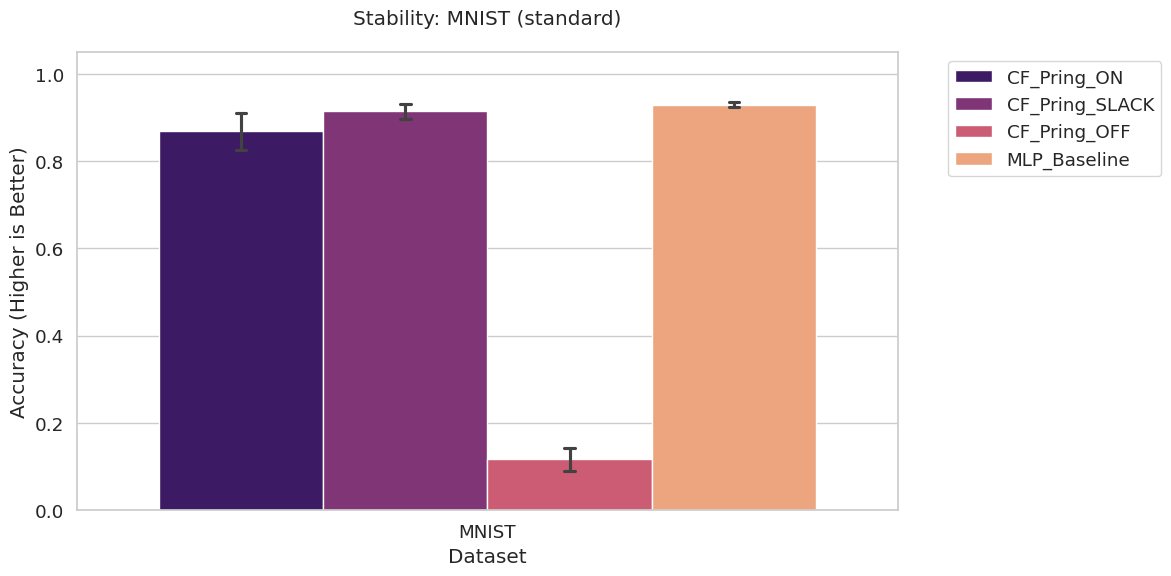

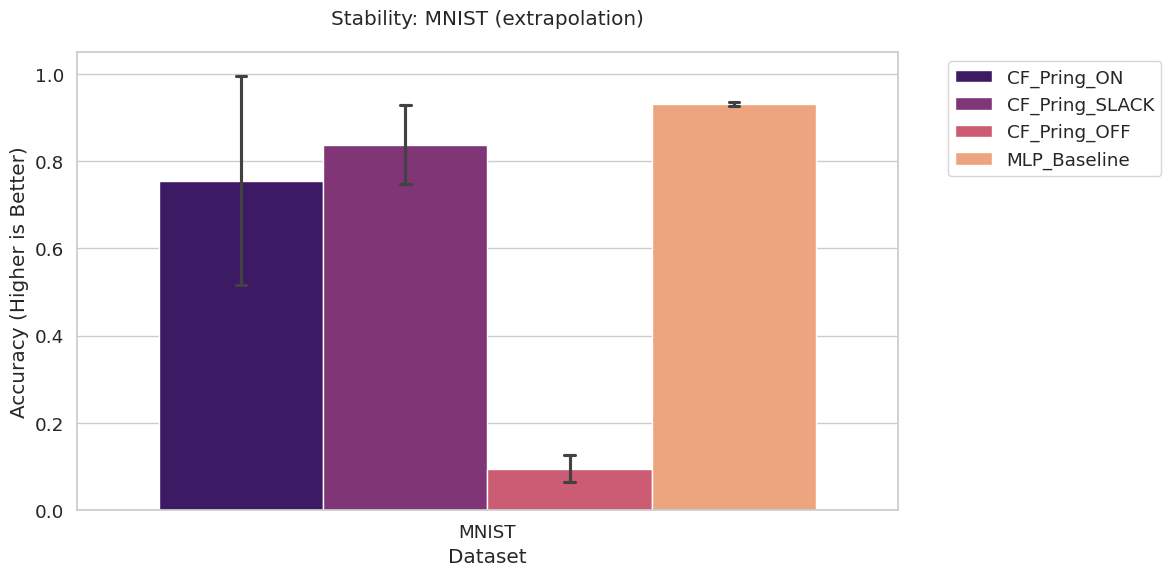

In [11]:
def plot_classification_boundary(model, dataset_name, stats, feature_indices=(0, 1), resolution=100, title=None):
    """
    FIXED: Added 'title' argument and .cpu() safety for GPU models.
    """
    model.eval()
    device = next(model.parameters()).device
    input_dim = stats['x_mean'].shape[0]
    
    # 1. Create grid
    x_range = torch.linspace(-3, 3, resolution)
    grid_x, grid_y = torch.meshgrid(x_range, x_range, indexing='ij')
    coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

    # 2. Anchor non-plotted features to 0 (the mean in normalized space)
    X_input = torch.zeros(resolution**2, input_dim).to(device)
    X_input[:, feature_indices[0]] = coords[:, 0]
    X_input[:, feature_indices[1]] = coords[:, 1]
    
    with torch.no_grad():
        logits = model(X_input)
        probs = torch.softmax(logits, dim=1)
        # Class 1 is usually the 'signal' in Magic/Waveform
        display_conf = probs[:, 1].reshape(resolution, resolution).cpu().numpy()

    # 3. Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(display_conf, extent=[-3, 3, -3, 3], origin='lower', 
               cmap='RdBu_r', alpha=0.8) 
    plt.colorbar(label='Probability (Class 1)')
    
    plt.title(title if title else f"Decision Boundary: {dataset_name}")
    plt.xlabel(f"Normalized Feature {feature_indices[0]}")
    plt.ylabel(f"Normalized Feature {feature_indices[1]}")
    plt.grid(False)
    plt.show()

def generate_study_reports(results_df, model_vault):
    for study_name in results_df['Study'].unique():
        print(f"\n--- [STUDY] {study_name} ---")
        study_df = results_df[results_df['Study'] == study_name]
        models_dict, data_pool = model_vault[study_name]
        
        # 1. Performance Summary (Bar charts)
        for dataset in study_df['Dataset'].unique():
            ds_df = study_df[study_df['Dataset'] == dataset]
            for mode in ["standard", "extrapolation"]:
                if mode in ds_df['Mode'].values:
                    plot_bar_chart(ds_df, mode=mode, title=f"{study_name}: {dataset} ({mode})")

        # 2. UNIVERSAL VISUALIZATION (Runs for all datasets)
        # 2. Universal Visualization
        for dataset in data_pool.keys():
            ds_info = data_pool[dataset]
            if ds_info.get('is_class', False):
                # Classification Boundary logic...
                pass
            else:
                # REGRESSION: Run the slice plot for Sinc, Runge, Nested, etc.
                plot_manifold_slices(models_dict, dataset, ds_info['stats'], None)

generate_study_reports(results_df, model_vault)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=3858fc3e-a203-49ba-bd24-3e14dec82b36' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>